In [18]:
import gseapy as gp
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

deg_dir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8")
outdir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_GSEA/CD8")
outdir.mkdir(exist_ok=True)

deg_files = {
    "CD8_GZMK__naive_Tcm": deg_dir / "DESeq2_age_CD8_GZMK__naive_Tcm.csv",
    "CD8_Tem": deg_dir / "DESeq2_age_CD8_Tem.csv",
    "CD8_naive_Tcm": deg_dir / "DESeq2_age_CD8_naive_Tcm.csv"
}

## GSEA

In [19]:
# Function to run preranked GSEA
def run_gsea(celltype_name, deg_file):
    
    print(f"Running GSEA for {celltype_name}")
    
    res = pd.read_csv(deg_file)
    
    # Need gene and stat columns from DESeq2
    res = res.dropna(subset=["gene", "stat"])
    
    # Remove duplicate genes
    res = res.drop_duplicates(subset="gene")
    
    # Create ranked list
    ranking = res[["gene", "stat"]].copy()
    ranking = ranking.sort_values("stat", ascending=False)
    
    # Output folder
    ct_outdir = outdir / celltype_name
    ct_outdir.mkdir(exist_ok=True)
    
    # Run GSEA
    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets="MSigDB_Hallmark_2020",
        outdir=str(ct_outdir),
        permutation_num=1000,
        seed=42,
        min_size=15,
        max_size=500,
        verbose=True
    )
    
    # Save result table
    gsea_df = pre_res.res2d
    gsea_df.to_csv(ct_outdir / f"GSEA_Hallmark_{celltype_name}.csv")
    
    return gsea_df

In [20]:
# Run GSEA
all_gsea = {}

for ct, file in deg_files.items():
    if file.exists():
        all_gsea[ct] = run_gsea(ct, file)
    else:
        print(f"Missing file for {ct}: {file}")

2026-05-18 16:32:02,934 [INFO] Parsing data files for GSEA.............................


2026-05-18 16:32:02,947 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:32:02,953 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:32:02,954 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-18 16:32:02,954 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD8_GZMK__naive_Tcm


2026-05-18 16:32:10,993 [INFO] Congratulations. GSEApy runs successfully................

2026-05-18 16:32:11,021 [INFO] Parsing data files for GSEA.............................
2026-05-18 16:32:11,033 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:32:11,039 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:32:11,039 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-18 16:32:11,039 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD8_Tem


2026-05-18 16:32:19,507 [INFO] Congratulations. GSEApy runs successfully................

2026-05-18 16:32:19,561 [INFO] Parsing data files for GSEA.............................
2026-05-18 16:32:19,576 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:32:19,581 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:32:19,582 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-18 16:32:19,582 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD8_naive_Tcm


2026-05-18 16:32:28,591 [INFO] Congratulations. GSEApy runs successfully................



In [21]:
# Combine GSEA results
combined = []

for ct, df in all_gsea.items():
    temp = df.copy()
    temp["cell_type"] = ct
    combined.append(temp)

gsea_combined = pd.concat(combined, axis=0)

gsea_combined.to_csv(outdir / "CD8_GSEA_Hallmark_combined.csv", index=False)

gsea_combined.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Oxidative Phosphorylation,-0.443399,-2.124652,0.0,0.0,0.0,85/198,19.96%,ATP5F1C;SLC25A5;ATP5F1B;TIMM8B;NDUFS2;UQCRC2;U...,CD8_GZMK__naive_Tcm
1,prerank,Epithelial Mesenchymal Transition,0.565354,2.052939,0.0,0.0,0.0,30/73,11.42%,IGFBP3;TIMP1;IL15;VIM;GLIPR1;ITGB1;ID2;ENO2;SG...,CD8_GZMK__naive_Tcm
2,prerank,IL-2/STAT5 Signaling,0.488642,1.950901,0.0,0.000499,0.001,72/155,18.67%,RORA;PTGER2;CD48;HOPX;AHNAK;PTCH1;IL2RA;GPR65;...,CD8_GZMK__naive_Tcm
3,prerank,Interferon Alpha Response,-0.439796,-1.894695,0.0,0.002507,0.005,44/93,19.19%,LGALS3BP;SELL;ISG15;GBP2;UBE2L6;IRF7;CNP;IRF9;...,CD8_GZMK__naive_Tcm
4,prerank,Coagulation,0.525566,1.835527,0.0,0.002664,0.008,14/56,6.80%,CPQ;CFH;TIMP1;ANXA1;CAPN2;DPP4;CLU;F8;CTSO;ISC...,CD8_GZMK__naive_Tcm


##### Significant GSEA pathways

In [22]:
gsea_combined.columns

Index(['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val',
       'Tag %', 'Gene %', 'Lead_genes', 'cell_type'],
      dtype='object')

In [23]:
sig_gsea = gsea_combined[
    gsea_combined["FDR q-val"] < 0.05
].copy()

sig_gsea = sig_gsea.sort_values(
    ["cell_type", "FDR q-val"]
)

sig_gsea.to_csv(
    outdir / "CD8_GSEA_Hallmark_significant.csv",
    index=False
)

sig_gsea.head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Oxidative Phosphorylation,-0.443399,-2.124652,0.0,0.0,0.0,85/198,19.96%,ATP5F1C;SLC25A5;ATP5F1B;TIMM8B;NDUFS2;UQCRC2;U...,CD8_GZMK__naive_Tcm
1,prerank,Epithelial Mesenchymal Transition,0.565354,2.052939,0.0,0.0,0.0,30/73,11.42%,IGFBP3;TIMP1;IL15;VIM;GLIPR1;ITGB1;ID2;ENO2;SG...,CD8_GZMK__naive_Tcm
2,prerank,IL-2/STAT5 Signaling,0.488642,1.950901,0.0,0.000499,0.001,72/155,18.67%,RORA;PTGER2;CD48;HOPX;AHNAK;PTCH1;IL2RA;GPR65;...,CD8_GZMK__naive_Tcm
3,prerank,Interferon Alpha Response,-0.439796,-1.894695,0.0,0.002507,0.005,44/93,19.19%,LGALS3BP;SELL;ISG15;GBP2;UBE2L6;IRF7;CNP;IRF9;...,CD8_GZMK__naive_Tcm
4,prerank,Coagulation,0.525566,1.835527,0.0,0.002664,0.008,14/56,6.80%,CPQ;CFH;TIMP1;ANXA1;CAPN2;DPP4;CLU;F8;CTSO;ISC...,CD8_GZMK__naive_Tcm
6,prerank,TNF-alpha Signaling via NF-kB,0.444554,1.801022,0.0,0.002747,0.011,74/154,23.40%,DUSP1;ID2;KLF6;IER5;SQSTM1;CLCF1;IL7R;BHLHE40;...,CD8_GZMK__naive_Tcm
8,prerank,Inflammatory Response,0.448691,1.767673,0.0,0.002797,0.014,44/119,18.61%,PTGER2;TIMP1;CD48;IL15;SLC4A4;GABBR1;CD40;IL2R...,CD8_GZMK__naive_Tcm
5,prerank,G2-M Checkpoint,-0.386415,-1.804514,0.0,0.003343,0.01,69/171,24.65%,SMC4;TACC3;H2BC12;HMGA1;LMNB1;HIF1A;STMN1;RAD2...,CD8_GZMK__naive_Tcm
7,prerank,E2F Targets,-0.374613,-1.781264,0.0,0.00351,0.014,47/180,15.12%,SMC4;TACC3;HMGA1;LMNB1;STMN1;PAICS;SMC6;LBR;EZ...,CD8_GZMK__naive_Tcm
10,prerank,Myc Targets V1,-0.343319,-1.650748,0.0,0.008625,0.043,103/196,28.82%,SERBP1;PPM1G;LSM2;RAD23B;NOP16;EIF3B;CCT2;PSMA...,CD8_GZMK__naive_Tcm


In [24]:
# Summary table
gsea_summary = sig_gsea[[
    "cell_type",
    "Term",
    "NES",
    "NOM p-val",
    "FDR q-val"
]].copy()

gsea_summary["direction"] = gsea_summary["NES"].apply(
    lambda x: "Up with age" if x > 0 else "Down with age"
)

gsea_summary = gsea_summary.sort_values(
    ["cell_type", "FDR q-val"]
)

gsea_summary.to_csv(
    outdir / "CD8_GSEA_Hallmark_summary.csv",
    index=False
)

gsea_summary.head(30)

,cell_type,Term,NES,NOM p-val,FDR q-val,direction
0,CD8_GZMK__naive_Tcm,Oxidative Phosphorylation,-2.124652,0.0,0.0,Down with age
1,CD8_GZMK__naive_Tcm,Epithelial Mesenchymal Transition,2.052939,0.0,0.0,Up with age
2,CD8_GZMK__naive_Tcm,IL-2/STAT5 Signaling,1.950901,0.0,0.000499,Up with age
3,CD8_GZMK__naive_Tcm,Interferon Alpha Response,-1.894695,0.0,0.002507,Down with age
4,CD8_GZMK__naive_Tcm,Coagulation,1.835527,0.0,0.002664,Up with age
6,CD8_GZMK__naive_Tcm,TNF-alpha Signaling via NF-kB,1.801022,0.0,0.002747,Up with age
8,CD8_GZMK__naive_Tcm,Inflammatory Response,1.767673,0.0,0.002797,Up with age
5,CD8_GZMK__naive_Tcm,G2-M Checkpoint,-1.804514,0.0,0.003343,Down with age
7,CD8_GZMK__naive_Tcm,E2F Targets,-1.781264,0.0,0.00351,Down with age
10,CD8_GZMK__naive_Tcm,Myc Targets V1,-1.650748,0.0,0.008625,Down with age


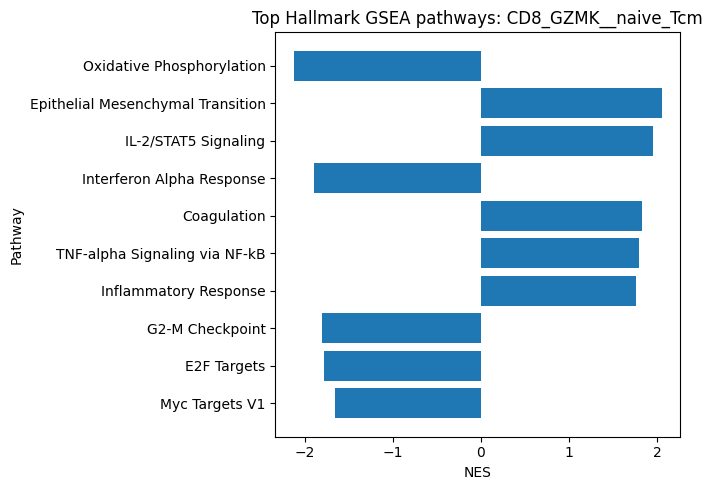

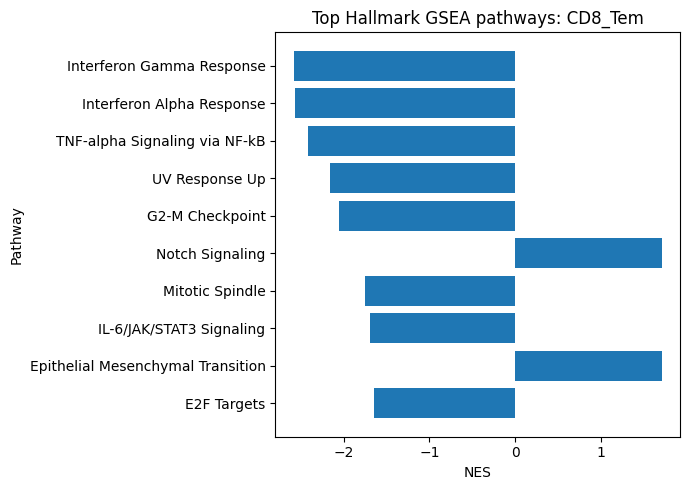

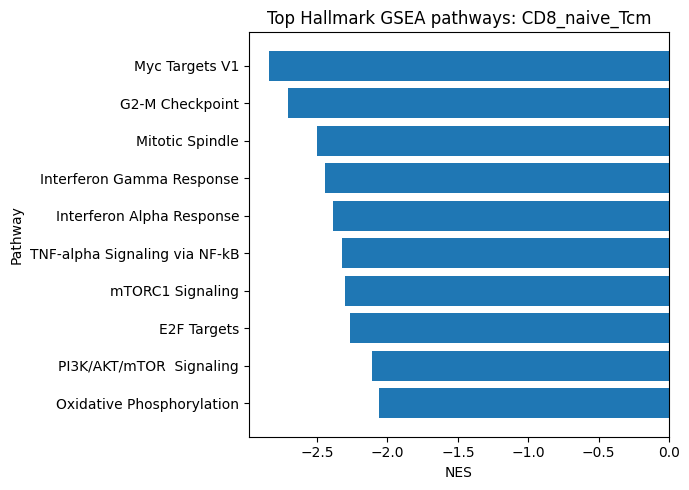

In [25]:
# Plot top GSEA pathways per cell type
for ct in gsea_summary["cell_type"].unique():
    
    df = gsea_summary[gsea_summary["cell_type"] == ct].copy()
    df = df.sort_values("FDR q-val").head(10)
    
    if df.empty:
        continue
    
    plt.figure(figsize=(7, 5))
    plt.barh(df["Term"], df["NES"])
    plt.xlabel("NES")
    plt.ylabel("Pathway")
    plt.title(f"Top Hallmark GSEA pathways: {ct}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    plt.savefig(outdir / f"GSEA_top_pathways_{ct}.png", dpi=300)
    plt.show()